<a href="https://colab.research.google.com/github/namitaannushajicambridge/imagecaptioning_SIC/blob/main/imagecaptioning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# IMAGE CAPTIONING SYSTEM (FAST VERSION)
# CNN (ResNet50) + Transformer Decoder
# Optimized for T4 GPU & ~8000 images
# ==========================================================

!pip install -q torch torchvision nltk pandas

import os
import zipfile
import ast
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from collections import Counter

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.tokenize import word_tokenize
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================================
# 1️⃣ UNZIP DATASET
# ==========================================================

zip_path = "/content/drive/MyDrive/imagecaption/archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

# ==========================================================
# 2️⃣ LOAD CSV FILES
# ==========================================================

train_df = pd.read_csv(os.path.join(extract_path, "train.csv"))
valid_df = pd.read_csv(os.path.join(extract_path, "valid.csv"))
test_df  = pd.read_csv(os.path.join(extract_path, "test.csv"))

def clean_caption(text):
    return ast.literal_eval(text)[0]

train_df["caption"] = train_df["captions"].apply(clean_caption)
valid_df["caption"] = valid_df["captions"].apply(clean_caption)
test_df["caption"]  = test_df["captions"].apply(clean_caption)

print("Train size:", len(train_df))
print("Columns:", train_df.columns)

# ==========================================================
# 3️⃣ BUILD VOCABULARY
# ==========================================================

def build_vocab(sentences, freq_threshold=3):
    counter = Counter()
    for sentence in sentences:
        tokens = word_tokenize(sentence.lower())
        counter.update(tokens)

    vocab = {"<PAD>":0, "<SOS>":1, "<EOS>":2, "<UNK>":3}
    idx = 4

    for word, freq in counter.items():
        if freq >= freq_threshold:
            vocab[word] = idx
            idx += 1
    return vocab

vocab = build_vocab(train_df["caption"].values)
vocab_size = len(vocab)
inv_vocab = {v:k for k,v in vocab.items()}

print("Vocab size:", vocab_size)

# ==========================================================
# 4️⃣ DATASET + COLLATE
# ==========================================================

class CaptionDataset(Dataset):
    def __init__(self, dataframe, root_dir, vocab, transform):
        self.df = dataframe
        self.root_dir = root_dir
        self.vocab = vocab
        self.transform = transform

    def numericalize(self, text):
        tokens = word_tokenize(text.lower())
        return [self.vocab.get(token, self.vocab["<UNK>"]) for token in tokens]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.df.iloc[idx]["filepath"])
        caption = self.df.iloc[idx]["caption"]

        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)

        caption_vec = [self.vocab["<SOS>"]]
        caption_vec += self.numericalize(caption)
        caption_vec.append(self.vocab["<EOS>"])

        return image, torch.tensor(caption_vec)

def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)

    lengths = [len(cap) for cap in captions]
    max_len = max(lengths)

    padded = torch.zeros(len(captions), max_len).long()
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap

    return images, padded

# 🔥 Proper ResNet normalization
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = CaptionDataset(train_df, extract_path, vocab, transform)
valid_dataset = CaptionDataset(valid_df, extract_path, vocab, transform)
test_dataset  = CaptionDataset(test_df, extract_path, vocab, transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

# ==========================================================
# 5️⃣ CNN ENCODER
# ==========================================================

class CNN_Encoder(nn.Module):
    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(weights="IMAGENET1K_V1")

        for param in resnet.parameters():
            param.requires_grad = False

        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.linear = nn.Linear(resnet.fc.in_features, embed_size)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)
        features = features.reshape(features.size(0), -1)
        features = self.linear(features)
        return features.unsqueeze(1)

# ==========================================================
# 6️⃣ TRANSFORMER DECODER
# ==========================================================

class TransformerDecoder(nn.Module):
    def __init__(self, embed_size, vocab_size, num_heads=8, num_layers=3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.pos = nn.Parameter(torch.randn(1, 200, embed_size))

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=embed_size,
            nhead=num_heads,
            dim_feedforward=embed_size*4,
            dropout=0.1
        )

        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers)
        self.fc_out = nn.Linear(embed_size, vocab_size)

    def forward(self, features, captions):
        embeddings = self.embedding(captions)
        embeddings += self.pos[:, :embeddings.size(1), :]

        embeddings = embeddings.permute(1,0,2)
        features = features.permute(1,0,2)

        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
            embeddings.size(0)
        ).to(device)

        out = self.transformer(embeddings, features, tgt_mask=tgt_mask)
        out = self.fc_out(out)

        return out.permute(1,0,2)

# ==========================================================
# 7️⃣ MODEL
# ==========================================================

class ImageCaptionModel(nn.Module):
    def __init__(self, embed_size, vocab_size):
        super().__init__()
        self.encoder = CNN_Encoder(embed_size)
        self.decoder = TransformerDecoder(embed_size, vocab_size)

    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs

model = ImageCaptionModel(512, vocab_size).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=vocab["<PAD>"])
optimizer = optim.Adam(model.parameters(), lr=3e-4)
scaler = torch.cuda.amp.GradScaler()

# ==========================================================
# 8️⃣ TRAINING (Mixed Precision Enabled)
# ==========================================================

epochs = 5
best_valid_loss = float("inf")

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for imgs, caps in train_loader:
        imgs = imgs.to(device)
        caps = caps.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs, caps[:,:-1])
            loss = criterion(
                outputs.reshape(-1, vocab_size),
                caps[:,1:].reshape(-1)
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    valid_loss = 0

    with torch.no_grad():
        for imgs, caps in valid_loader:
            imgs = imgs.to(device)
            caps = caps.to(device)

            outputs = model(imgs, caps[:,:-1])
            loss = criterion(
                outputs.reshape(-1, vocab_size),
                caps[:,1:].reshape(-1)
            )

            valid_loss += loss.item()

    valid_loss /= len(valid_loader)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Valid Loss: {valid_loss:.4f}")
    print("-"*40)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "best_model.pth")

print("Training Complete!")

# ==========================================================
# 9️⃣ LOAD BEST MODEL
# ==========================================================

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# ==========================================================
# 🔟 GENERATE CAPTION
# ==========================================================

def generate_caption(model, image_path, max_len=30):

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.encoder(image)
        caption = [vocab["<SOS>"]]

        for _ in range(max_len):
            cap_tensor = torch.tensor(caption).unsqueeze(0).to(device)
            outputs = model.decoder(features, cap_tensor)
            next_token = outputs.argmax(2)[:,-1].item()

            caption.append(next_token)

            if next_token == vocab["<EOS>"]:
                break

    words = [inv_vocab[idx] for idx in caption if idx not in [0,1,2]]
    return " ".join(words)

# ==========================================================
# TEST ON ONE IMAGE
# ==========================================================

sample_img = os.path.join(extract_path, test_df.iloc[0]["filepath"])
print("Generated Caption:")
print(generate_caption(model, sample_img))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive
Using device: cuda
Dataset extracted!
Train size: 8734
Columns: Index(['captions', 'filepath', 'caption'], dtype='object')
Vocab size: 2309
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 93.9MB/s]
/tmp/ipython-input-3513997273.py:243: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipython-input-3513997273.py:263: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1
Train Loss: 2.8389
Valid Loss: 2.3861
----------------------------------------
Epoch 2
Train Loss: 1.7579
Valid Loss: 2.1119
----------------------------------------
Epoch 3
Train Loss: 1.3986
Valid Loss: 2.0097
----------------------------------------
Epoch 4
Train Loss: 1.1851
Valid Loss: 1.9776
----------------------------------------
Epoch 5
Train Loss: 1.0279
Valid Loss: 1.9469
----------------------------------------
Training Complete!
Generated Caption:
many aircraft are parked near several buildings and green trees.many planes are parked near several buildings and green trees.many planes are parked near several buildings and green trees.many planes are


In [ ]:
drive_model_path = "/content/drive/MyDrive/imagecaption/best_model.pth"
torch.save(model.state_dict(), drive_model_path)
print("Model saved to Drive!")


Model saved to Drive!


In [ ]:
model = ImageCaptionModel(512, vocab_size).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/imagecaption/best_model.pth"))
model.eval()


ImageCaptionModel(
  (encoder): CNN_Encoder(
    (resnet): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=Tru

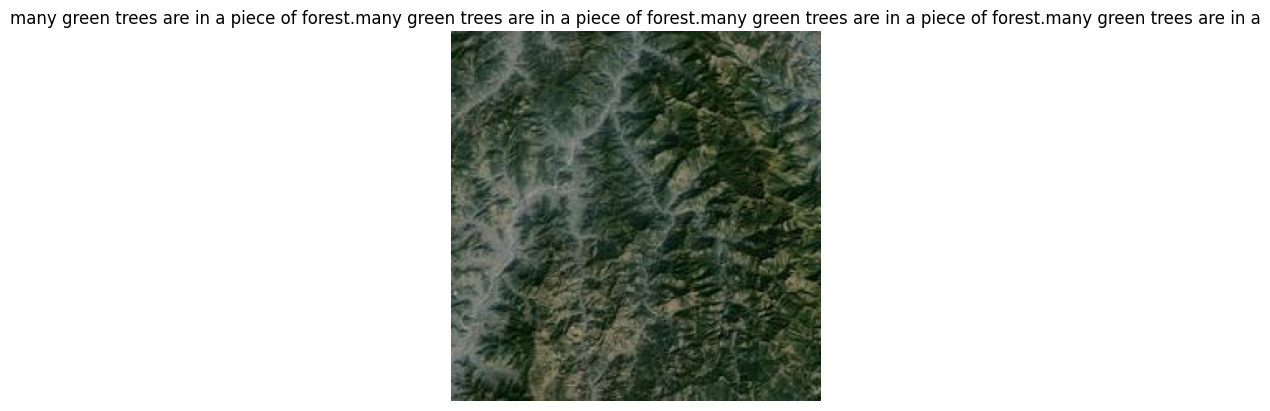

In [ ]:
import random
from matplotlib import pyplot as plt

for _ in range(1):
    idx = random.randint(0, len(test_df)-1)
    image_path = os.path.join(extract_path, test_df.iloc[idx]["filepath"])

    img = Image.open(image_path)
    caption = generate_caption(model, image_path)

    plt.imshow(img)
    plt.axis("off")
    plt.title(caption)
    plt.show()
